In [5]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from datetime import datetime
from tqdm import tqdm
from pprint import pprint
from matplotlib import pyplot as plt

### calculate metrix

In [6]:
def get_daily_return(df: pd.DataFrame) -> pd.DataFrame:
    """
    calculate daily return in dataframe
    """
    df = df.pct_change(fill_method = None).fillna(0).drop(index = df.index[0])
    cols_to_drop = [col for col in ["6739", "3529"] if col in df.columns]
    if cols_to_drop:
        df = df.drop(columns = cols_to_drop)
    return df

def get_daily_mean(df: pd.DataFrame) -> pd.Series:
    """
    daily geometric mean
    """
    one_plus = 1 + df
    mean = (one_plus.product(axis = 0)) ** (1 / df.shape[0]) - 1

    return mean

def get_daily_cov_metrix(df: pd.DataFrame) -> pd.DataFrame:
    """
    daily covariance metrix
    """
    cov_metrix = df.cov()
    return cov_metrix

### get portfolio's metrix

In [7]:
def get_portfolio_return(weights: pd.Series, annualized_returns: pd.Series) -> float:
    """
    a portfolio's return
    """
    return np.dot(weights, annualized_returns)

def get_portfolio_volatility(weights: pd.Series, annualized_cov_metrix: pd.DataFrame) -> float:
    """
    a portfolio's volatility(standard deviation)
    """
    return np.sqrt(np.dot(weights.T, np.dot(annualized_cov_metrix, weights)))

### montecarlo

In [8]:
def run_monte_carlo_simulation(
    annualized_avg_returns: pd.Series,
    annualized_cov_matrix: pd.DataFrame,
    num_portfolios: int = 50000, # 訓練次數
    risk_free_rate: float = 0
) -> tuple[np.ndarray, np.ndarray]:
    """
    runs a Monte Carlo simulation to generate random portfolios for the efficient frontier.
    """
    num_assets = len(annualized_avg_returns)
    results_array = np.zeros((3, num_portfolios))
    weights_array = np.zeros((num_portfolios, num_assets))

    for i in tqdm(range(num_portfolios)):
        weights = np.random.random(num_assets)
        weights /= np.sum(weights)

        port_return = get_portfolio_return(weights, annualized_avg_returns)
        port_volatility = get_portfolio_volatility(weights, annualized_cov_matrix)
        
        sharpe_ratio = (port_return - risk_free_rate) / port_volatility if port_volatility != 0 else 0

        results_array[0, i] = port_volatility
        results_array[1, i] = port_return
        results_array[2, i] = sharpe_ratio
        weights_array[i, :] = weights
    
    return results_array, weights_array

### find the optimized portfolio

In [9]:
def portfolio_entropy(weights):
    # 加一個很小的數避免 log(0)
    return -np.sum(weights * np.log(weights + 1e-9))

def mean_variance_with_entropy(weights, annualized_cov_metrix, lam=0.9):
    """
    lam: 權衡參數 (0~1)，越大越偏重風險最小化，越小越偏重分散化
    """
    risk = get_portfolio_volatility(weights, annualized_cov_metrix) ** 2  # 用變異數
    entropy = portfolio_entropy(weights)
    return lam * risk - (1 - lam) * entropy

def minimize_volatility(
        weights: np.ndarray,
        annualized_return: pd.Series,
        annualized_cov_metrix: pd.DataFrame
) -> float:
    """
    objective function
    """
    return get_portfolio_volatility(weights, annualized_cov_metrix)

def maximize_sharpe(
        weights: np.ndarray,
        annualized_return: pd.Series,
        annualized_cov_metrix: pd.DataFrame,
        risk_free_rate: float = 0
) -> float:
    """
    objective function to min negative sharpe 
    """
    port_vol = get_portfolio_volatility(weights, annualized_cov_metrix)
    port_ret = get_portfolio_return(weights, annualized_return)
    # 避免除以0
    if port_vol == 0:
        return np.inf
    return -((port_ret - risk_free_rate) / port_vol)

def find_diversified_portfolio(
    annualized_avg_ret: pd.Series,
    annualized_cov_metrix: pd.DataFrame,
    lam: float = 0.9
):
    """
    regularize by entropy
    """
    num_assets = len(annualized_avg_ret)
    bounds = tuple((0.0, 1.0) for _ in range(num_assets))
    constraints = ({"type": "eq", "fun": lambda x: np.sum(x) - 1})
    initial_weights = np.array(num_assets * [1. / num_assets])
    
    result = minimize(mean_variance_with_entropy, initial_weights,
                      args = (annualized_cov_metrix, lam),
                      method = "SLSQP", bounds = bounds, constraints = constraints)
    return result

def find_optimized_portfolio(
        annualized_avg_ret: pd.Series,
        annualized_cov_metrix: pd.DataFrame
) -> tuple:
    """
    find MVP and best portfolio
    """
    num_assets = len(annualized_avg_ret)

    # 權重總合為1
    constraint = ({"type": "eq", "fun": lambda x: np.sum(x) - 1}) 
    # 權重範圍介於0~1
    bound = tuple((0.0, 1.0) for asset in range(num_assets))
    # 猜測初始權重(均勻分配)
    initial_weights = np.array(num_assets * [1. / num_assets, ])

    min_vol_port = minimize(minimize_volatility, initial_weights, args = (annualized_avg_ret, annualized_cov_metrix),
                            method = "SLSQP", bounds = bound, constraints = constraint)
    max_sharpe_port = minimize(maximize_sharpe, initial_weights,args = (annualized_avg_ret, annualized_cov_metrix),
                               method = "SLSQP", bounds = bound, constraints = constraint)
    
    return min_vol_port, max_sharpe_port

### plot efficient frontier

In [10]:
def calculate_efficient_frontier_curve(
    annualized_avg_ret: pd.Series,
    annualized_cov_metrix: pd.DataFrame,
    num_points: int = 100 # 曲線上點的數量
) -> tuple:
    """
    Calculates points for the efficient frontier curve.
    """
    num_assets = len(annualized_avg_ret)

    # 權重總合為1
    weights_sum_to_1_constraint = ({"type": "eq", "fun": lambda x: np.sum(x) - 1})
    # 權重範圍介於0~1
    bounds = tuple((0.0, 1.0) for asset in range(num_assets))

    # MVP 的報酬，作為曲線的起始點
    initial_weights = np.array(num_assets * [1. / num_assets, ])
    min_vol_port_result = minimize(minimize_volatility, initial_weights, 
                                   args=(annualized_avg_ret, annualized_cov_metrix),
                                   method="SLSQP", bounds=bounds, 
                                   constraints=weights_sum_to_1_constraint)
    
    min_vol_ret_val = get_portfolio_return(min_vol_port_result.x, annualized_avg_ret)
    
    target_returns = np.linspace(min_vol_ret_val, annualized_avg_ret.max() * 1.1, num_points) # 考慮稍高於最高個股報酬
    
    frontier_volatilities = []
    frontier_returns = []

    for target_return in tqdm(target_returns, desc="Calculating Efficient Frontier"):
        return_constraint = ({'type': 'eq', 'fun': lambda x: get_portfolio_return(x, annualized_avg_ret) - target_return})
        
        # 將所有約束整合
        constraints = [weights_sum_to_1_constraint, return_constraint]

        # 為每個目標報酬率，找到最小波動率的投資組合
        optimized_result = minimize(minimize_volatility, initial_weights, 
                                    args=(annualized_avg_ret, annualized_cov_metrix),
                                    method="SLSQP", bounds=bounds, 
                                    constraints=constraints)
        
        # 檢查優化是否成功
        if optimized_result.success:
            frontier_volatilities.append(get_portfolio_volatility(optimized_result.x, annualized_cov_metrix))
            frontier_returns.append(get_portfolio_return(optimized_result.x, annualized_avg_ret))
        else:
            pass

    return np.array(frontier_volatilities), np.array(frontier_returns)

In [11]:
def plot_frontier_subplots(
    portfolio_data: list,
    titles: list,
    figsize: tuple = (18, 6)
):
    """
    畫多個投資組合的有效前緣圖
    portfolio_data: list of dict，每個 dict 包含：
        {
            "results": Monte Carlo 結果 (3 x N array),
            "frontier_vol": frontier vol array 或 None,
            "frontier_ret": frontier ret array 或 None,
            "min_vol": (vol, ret, sharpe) 或 None,
            "max_sharpe": (vol, ret, sharpe) 或 None,
            "diversified": (vol, ret, sharpe) 或 None
        }
    titles: list，子圖標題
    figsize: 圖片大小
    """
    fig, axes = plt.subplots(1, len(portfolio_data), figsize=figsize, sharey=True)
    plt.subplots_adjust(wspace=0.3)

    for ax, data, title in zip(axes, portfolio_data, titles):
        results = data.get("results")
        f_vol = data.get("frontier_vol")
        f_ret = data.get("frontier_ret")
        min_vol = data.get("min_vol")
        max_sharpe = data.get("max_sharpe")
        diversified = data.get("diversified")

        # Monte Carlo
        if results is not None and results.shape[1] > 0:
            ax.scatter(results[0, :], results[1, :], c=results[2, :],
                       cmap='viridis', marker='o', s=8, alpha=0.5)
        # Frontier
        if f_vol is not None and f_ret is not None and len(f_vol) > 0:
            sort_idx = np.argsort(f_vol)
            ax.plot(f_vol[sort_idx], f_ret[sort_idx], 'k--', linewidth=2, label='Efficient Frontier')
        # Min Vol
        if min_vol is not None:
            vol, ret, sharpe = min_vol
            ax.scatter(vol, ret, color='red', s=40, label='Min Vol')
            ax.annotate(f'Sharpe: {sharpe:.2f}', (vol, ret), textcoords="offset points", xytext=(10, 5), ha='center',
                        bbox=dict(boxstyle="round,pad=0.2", fc="lightyellow", ec="b", lw=0.5, alpha=0.8))
        # Max Sharpe
        if max_sharpe is not None:
            vol, ret, sharpe = max_sharpe
            ax.scatter(vol, ret, color='green', s=40, label='Max Sharpe')
            ax.annotate(f'Sharpe: {sharpe:.2f}', (vol, ret), textcoords="offset points", xytext=(10, -25), ha='center',
                        bbox=dict(boxstyle="round,pad=0.2", fc="lightgreen", ec="b", lw=0.5, alpha=0.8))
        # Diversified
        if diversified is not None:
            vol, ret, sharpe = diversified
            ax.scatter(vol, ret, color='blue', s=40, label='Diversified')
            ax.annotate(f'Sharpe: {sharpe:.2f}', (vol, ret), textcoords="offset points", xytext=(10, -25), ha='center',
                        bbox=dict(boxstyle="round,pad=0.2", fc="lightblue", ec="b", lw=0.5, alpha=0.8))

        # 標籤
        ax.set_title(title)
        ax.set_xlabel('Volatility')
        ax.set_ylabel('Return')
        ax.legend()
        ax.grid(True)

    plt.suptitle('Efficient Frontiers by Sector', fontsize=16)
    plt.show()

### execute

In [12]:
# import data
# 分軟體、硬體、能源
hard_ware_prices = pd.read_csv("hard_ware_prices.csv", index_col = "Date").loc["2022-01-03": "2024-12-31"]
soft_ware_prices = pd.read_csv("soft_ware_prices.csv", index_col = "Date").loc["2022-01-03": "2024-12-31"]
energy_prices = pd.read_csv("energy_prices.csv", index_col = "Date").loc["2022-01-03": "2024-12-31"]

In [13]:
# get metrix
daily_ret_hard = get_daily_return(hard_ware_prices)
daily_ret_soft = get_daily_return(soft_ware_prices)
daily_ret_energy = get_daily_return(energy_prices)

daily_mean_hard = get_daily_mean(daily_ret_hard)
daily_mean_soft = get_daily_mean(daily_ret_soft)
daily_mean_energy = get_daily_mean(daily_ret_energy)

daily_cov_metrix_hard = get_daily_cov_metrix(daily_ret_hard)
daily_cov_metrix_soft = get_daily_cov_metrix(daily_ret_soft)
daily_cov_metrix_energy = get_daily_cov_metrix(daily_ret_energy)

annualized_mean_hard = daily_mean_hard * 252 # 252 表年化，但參數可調
annualized_mean_soft = daily_mean_soft * 252 
annualized_mean_energy = daily_mean_energy * 252

annualized_cov_metrix_hard = daily_cov_metrix_hard * 252
annualized_cov_metrix_soft = daily_cov_metrix_soft * 252
annualized_cov_metrix_energy = daily_cov_metrix_energy * 252

# monte carlo simulation
results_hard, weight_array_hard = run_monte_carlo_simulation(
    annualized_avg_returns = annualized_mean_hard,
    annualized_cov_matrix = annualized_cov_metrix_hard,
    num_portfolios = 50000
)
results_soft, weight_array_soft = run_monte_carlo_simulation(
    annualized_avg_returns = annualized_mean_soft,
    annualized_cov_matrix = annualized_cov_metrix_soft,
    num_portfolios = 50000
)
results_energy, weight_array_energy = run_monte_carlo_simulation(
    annualized_avg_returns = annualized_mean_energy,
    annualized_cov_matrix = annualized_cov_metrix_energy,
    num_portfolios = 50000
)

100%|██████████| 50000/50000 [00:02<00:00, 23501.42it/s]


In [14]:
# find optimized portfolio
min_vol_port_hard, max_sharpe_port_hard = find_optimized_portfolio(
    annualized_avg_ret = annualized_mean_hard,
    annualized_cov_metrix = annualized_cov_metrix_hard
)
min_vol_port_soft, max_sharpe_port_soft = find_optimized_portfolio(
    annualized_avg_ret = annualized_mean_soft,
    annualized_cov_metrix = annualized_cov_metrix_soft
)
min_vol_port_energy, max_sharpe_port_energy = find_optimized_portfolio(
    annualized_avg_ret = annualized_mean_energy,
    annualized_cov_metrix = annualized_cov_metrix_energy
)

# extract target portfolios' metrix
min_vol_ret_hard = get_portfolio_return(min_vol_port_hard.x, annualized_mean_hard)
min_vol_ret_soft = get_portfolio_return(min_vol_port_soft.x, annualized_mean_soft)
min_vol_ret_energy = get_portfolio_return(min_vol_port_energy.x, annualized_mean_energy)

min_vol_vol_hard = get_portfolio_volatility(min_vol_port_hard.x, annualized_cov_metrix_hard)
min_vol_vol_soft = get_portfolio_volatility(min_vol_port_soft.x, annualized_cov_metrix_soft)
min_vol_vol_energy = get_portfolio_volatility(min_vol_port_energy.x, annualized_cov_metrix_energy)

max_sharpe_ret_hard = get_portfolio_return(max_sharpe_port_hard.x, annualized_mean_hard)
max_sharpe_ret_soft = get_portfolio_return(max_sharpe_port_soft.x, annualized_mean_soft)
max_sharpe_ret_energy = get_portfolio_return(max_sharpe_port_energy.x, annualized_mean_energy)

max_sharpe_vol_hard = get_portfolio_volatility(max_sharpe_port_hard.x, annualized_cov_metrix_hard)
max_sharpe_vol_soft = get_portfolio_volatility(max_sharpe_port_soft.x, annualized_cov_metrix_soft)
max_sharpe_vol_energy = get_portfolio_volatility(max_sharpe_port_energy.x, annualized_cov_metrix_energy)

max_sharpe_ratio_hard = max_sharpe_ret_hard / max_sharpe_vol_hard
max_sharpe_ratio_soft = max_sharpe_ret_soft / max_sharpe_vol_soft
max_sharpe_ratio_energy = max_sharpe_ret_energy / max_sharpe_vol_energy

div_port_hard = find_diversified_portfolio(
    annualized_avg_ret = annualized_mean_hard,
    annualized_cov_metrix = annualized_cov_metrix_hard,
    lam = 0.9
)
div_port_soft = find_diversified_portfolio(
    annualized_avg_ret = annualized_mean_soft,
    annualized_cov_metrix = annualized_cov_metrix_soft,
    lam = 0.9
)
div_port_energy = find_diversified_portfolio(
    annualized_avg_ret = annualized_mean_energy,
    annualized_cov_metrix = annualized_cov_metrix_energy,
    lam = 0.9
)

div_weights_hard = div_port_hard.x
div_weights_soft = div_port_soft.x
div_weights_energy = div_port_energy.x

div_ret_hard = get_portfolio_return(div_weights_hard, annualized_mean_hard)
div_ret_soft = get_portfolio_return(div_weights_soft, annualized_mean_soft)
div_ret_energy = get_portfolio_return(div_weights_energy, annualized_mean_energy)

div_vol_hard = get_portfolio_volatility(div_weights_hard, annualized_cov_metrix_hard)
div_vol_soft = get_portfolio_volatility(div_weights_soft, annualized_cov_metrix_soft)
div_vol_energy = get_portfolio_volatility(div_weights_energy, annualized_cov_metrix_energy)

div_sharpe_ratio_hard = div_ret_hard / div_vol_hard
div_sharpe_ratio_soft = div_ret_soft / div_vol_soft
div_sharpe_ratio_energy = div_ret_energy / div_vol_energy

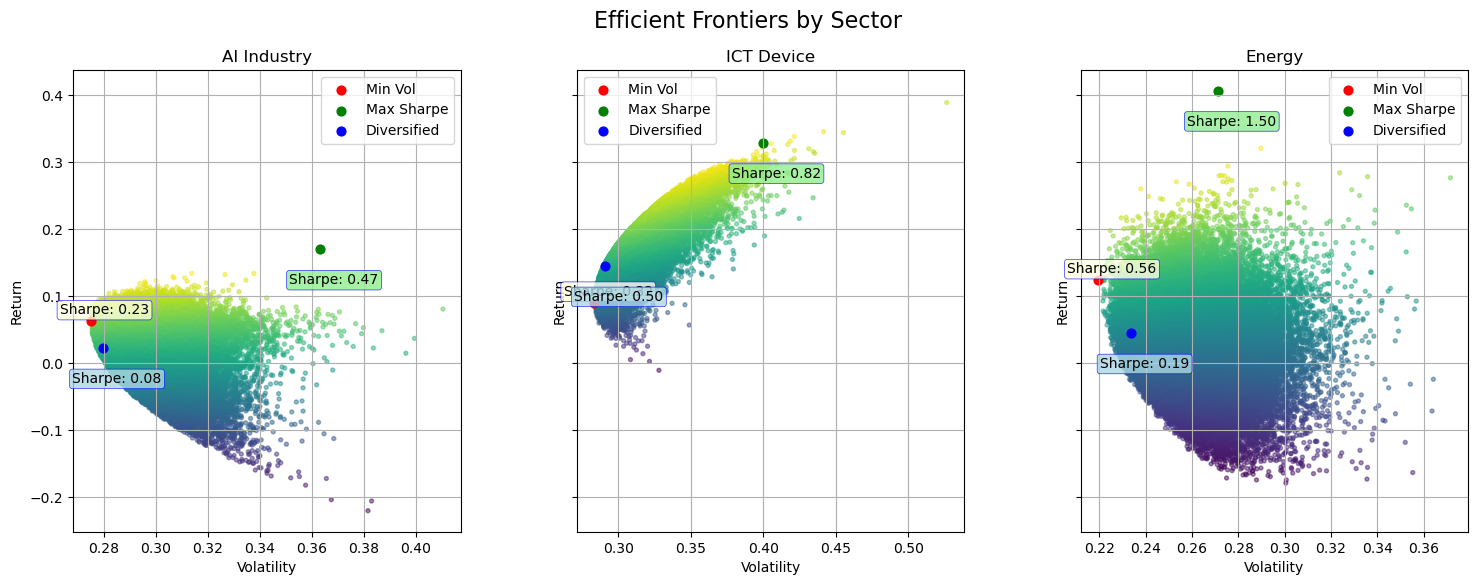

In [59]:
# plot
portfolio_data = [
    {
        "results": results_hard,
        "frontier_vol": None,
        "frontier_ret": None,
        "min_vol": (min_vol_vol_hard, min_vol_ret_hard, min_vol_ret_hard/min_vol_vol_hard),
        "max_sharpe": (max_sharpe_vol_hard, max_sharpe_ret_hard, max_sharpe_ratio_hard),
        "diversified": (div_vol_hard, div_ret_hard, div_sharpe_ratio_hard)
    },
    {
        "results": results_soft,
        "frontier_vol": None,
        "frontier_ret": None,
        "min_vol": (min_vol_vol_soft, min_vol_ret_soft, min_vol_ret_soft/min_vol_vol_soft),
        "max_sharpe": (max_sharpe_vol_soft, max_sharpe_ret_soft, max_sharpe_ratio_soft),
        "diversified": (div_vol_soft, div_ret_soft, div_sharpe_ratio_soft)
    },
    {
        "results": results_energy,
        "frontier_vol": None,
        "frontier_ret": None,
        "min_vol": (min_vol_vol_energy, min_vol_ret_energy, min_vol_ret_energy/min_vol_vol_energy),
        "max_sharpe": (max_sharpe_vol_energy, max_sharpe_ret_energy, max_sharpe_ratio_energy),
        "diversified": (div_vol_energy, div_ret_energy, div_sharpe_ratio_energy)
    }
]

plot_frontier_subplots(portfolio_data, titles=['AI Industry', 'ICT Device', 'Energy'])

In [16]:
# to test
investment = pd.Series(np.array(max_sharpe_port_hard.x) * 50_000_000, index = annualized_mean_hard.index)
investment = investment.round(0).astype(int)
print(np.array(max_sharpe_port_soft.x).round(10))

[0.         0.         0.04339724 0.23699104 0.23560162 0.4840101 ]


### combine all of the portfolio

In [17]:
# pre-process bond data
bond_prices = pd.read_csv("bond_prices.csv", index_col = "Date")
daily_ret_bond = get_daily_return(bond_prices)
# get bond metrix
daily_mean_bond = get_daily_mean(daily_ret_bond)
daily_cov_metrix_bond = get_daily_cov_metrix(daily_ret_bond)
# get annualized metrix
annualized_mean_bond = daily_mean_bond * 252

In [18]:
# calculate portfolio returns
port_ret_hard = daily_ret_hard.dot(max_sharpe_port_hard.x)
port_ret_soft = daily_ret_soft.dot(max_sharpe_port_soft.x)
port_ret_energy = daily_ret_energy.dot(max_sharpe_port_energy.x)

# combine all of the portfolio
group_ret = pd.concat([
    port_ret_hard.rename("Hard_Ware"),
    port_ret_soft.rename("Soft_Ware"),
    port_ret_energy.rename("Energy"),
    daily_ret_bond.rename(columns = {"00679b": "Bond"})
], axis = 1)

In [19]:
# get annualized matrix
mean_groups_daily = (1 + group_ret).prod() ** (1 / len(group_ret)) - 1
annualized_mean_group = mean_groups_daily * 252
annualized_cov_metrix_group = group_ret.cov() * 252

In [20]:
# get portfolio and frontier
results_group, weights_group = run_monte_carlo_simulation(
    annualized_avg_returns = annualized_mean_group,
    annualized_cov_matrix = annualized_cov_metrix_group,
    num_portfolios = 50000
)

min_vol_port_group, max_sharpe_port_group = find_optimized_portfolio(
    annualized_avg_ret = annualized_mean_group,
    annualized_cov_metrix = annualized_cov_metrix_group
)
min_vol_ret_group = get_portfolio_return(min_vol_port_group.x, annualized_mean_group)
min_vol_vol_group = get_portfolio_volatility(min_vol_port_group.x, annualized_cov_metrix_group)
min_vol_sharpe = min_vol_ret_group / min_vol_vol_group
max_sharpe_ret_group = get_portfolio_return(max_sharpe_port_group.x, annualized_mean_group)
max_sharpe_vol_group = get_portfolio_volatility(max_sharpe_port_group.x, annualized_cov_metrix_group)
max_sharpe_sharpe = max_sharpe_ret_group / max_sharpe_vol_group

frontier_vol_groups, frontier_ret_groups = calculate_efficient_frontier_curve(
    annualized_avg_ret = annualized_mean_group,
    annualized_cov_metrix = annualized_cov_metrix_group
)

div_port_group = find_diversified_portfolio(
    annualized_avg_ret = annualized_mean_group,
    annualized_cov_metrix = annualized_cov_metrix_group,
    lam = 0.75
)
div_weights_group = div_port_group.x
div_ret_group = get_portfolio_return(div_port_group.x, annualized_mean_group)
div_vol_group = get_portfolio_volatility(div_port_group.x, annualized_cov_metrix_group)
div_sharpe = div_ret_group / div_vol_group

Calculating Efficient Frontier: 100%|██████████| 100/100 [00:00<00:00, 134.95it/s]


In [21]:
# to test
investment_group = pd.Series(np.array(min_vol_port_group.x) * 50_000_000, index = annualized_mean_group.index)
investment_group = investment_group.round(0).astype(int)
print(investment_group)
print(np.array(div_port_group.x).round(10))

Hard_Ware     2027211
Soft_Ware     2089400
Energy        8040920
00679B       37842469
dtype: int64
[0.22632809 0.21860163 0.25045931 0.30461097]


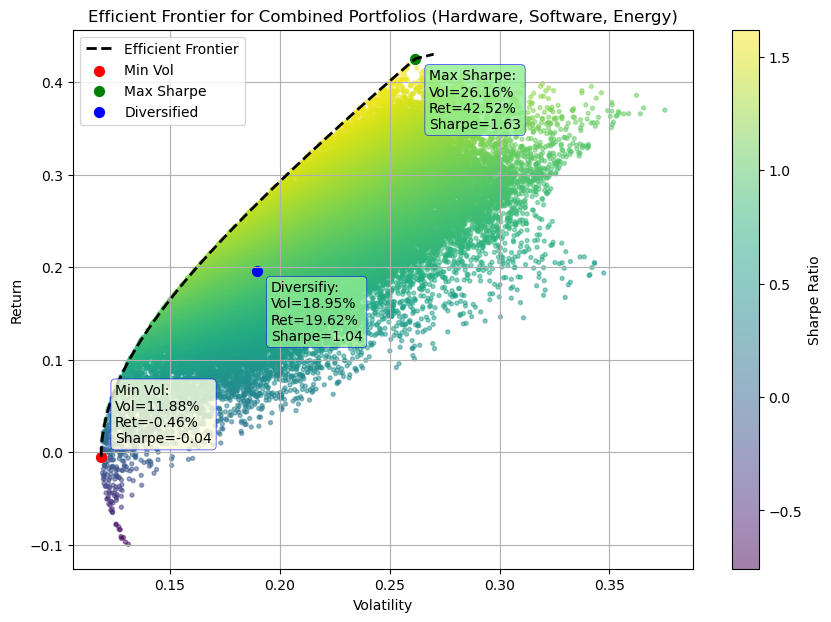

In [22]:
plt.figure(figsize = (10, 7))
# Monte Carlo 點
scatter = plt.scatter(results_group[0,:], results_group[1,:], c = results_group[2,:],
                      cmap = 'viridis', marker = 'o', s = 8, alpha = 0.5)
plt.colorbar(scatter, label = 'Sharpe Ratio')

# 效率前緣
sort_idx = np.argsort(frontier_vol_groups)
plt.plot(frontier_vol_groups[sort_idx], frontier_ret_groups[sort_idx], 'k--', lw = 2, label = 'Efficient Frontier')

# Min Vol

plt.scatter(min_vol_vol_group, min_vol_ret_group, color = 'red', s = 50, label = 'Min Vol')
plt.annotate(f'Min Vol:\nVol={min_vol_vol_group:.2%}\nRet={min_vol_ret_group:.2%}\nSharpe={min_vol_sharpe:.2f}',
             (min_vol_vol_group, min_vol_ret_group), textcoords="offset points", xytext=(10, 10), ha='left',
             bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="b", lw=0.5, alpha=0.8))

# Max Sharpe
plt.scatter(max_sharpe_vol_group, max_sharpe_ret_group, color='green', s=50, label='Max Sharpe')
plt.annotate(f'Max Sharpe:\nVol={max_sharpe_vol_group:.2%}\nRet={max_sharpe_ret_group:.2%}\nSharpe={max_sharpe_sharpe:.2f}',
             (max_sharpe_vol_group, max_sharpe_ret_group), textcoords="offset points", xytext=(10, -50), ha='left',
             bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="b", lw=0.5, alpha=0.8))

# Diversified
plt.scatter(div_vol_group, div_ret_group, color = 'blue', s = 50, label = 'Diversified')
plt.annotate(f'Diversifiy:\nVol={div_vol_group:.2%}\nRet={div_ret_group:.2%}\nSharpe={div_sharpe:.2f}',
             (div_vol_group, div_ret_group), textcoords="offset points", xytext=(10, -50), ha='left',
             bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", ec="b", lw=0.5, alpha=0.8))


plt.title('Efficient Frontier for Combined Portfolios (Hardware, Software, Energy)')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
# group-level 權重
w_group = div_port_group.x  # [HardWare, SoftWare, Energy, Bond]

# 各 group 內部權重
w_hard = max_sharpe_port_hard.x
w_soft = max_sharpe_port_soft.x
w_energy = max_sharpe_port_energy.x
w_bond = 1

final_weights_hard = w_group[0] * w_hard
final_weights_soft = w_group[1] * w_soft
final_weights_energy = w_group[2] * w_energy
final_weights_bond = w_group[3] * w_bond

final_weights = pd.concat([
    pd.Series(final_weights_hard.astype(float), index = annualized_mean_hard.index),
    pd.Series(final_weights_soft.astype(float), index = annualized_mean_soft.index),
    pd.Series(final_weights_energy.astype(float), index = annualized_mean_energy.index),
    pd.Series(final_weights_bond.astype(float), index = annualized_mean_bond.index)
])

final_weights_secter = final_weights[final_weights > 0]
final_weights = final_weights_secter / final_weights_secter.sum()
final_weights = final_weights.sort_values(ascending = False)
final_weights = final_weights

final_amount = final_weights_secter
print(w_group.round(10)*50000000)

[11316404.465 10930081.485 12522965.625 15230548.425]


In [55]:
files = [
    "hard_ware_prices.csv",
    "soft_ware_prices.csv",
    "energy_prices.csv",
    "bond_prices.csv",
    "benchmark_prices.csv"
]
dfs = [pd.read_csv(f, index_col = "Date") for f in files]
prices = pd.concat(dfs, axis = 1)
prices = prices.loc["2025-01-01": ]

benchmark_prices = prices["0050"]
benchmark_prices.loc["2025-06-18": ] = benchmark_prices.loc["2025-06-18": ] * 4

In [56]:
sorted_weights = pd.Series(0.0, index = prices.columns)
sorted_weights.update(final_weights)
weighted_prices = prices * sorted_weights

In [57]:
portfolio_value = weighted_prices.sum(axis = 1)
port_returns = portfolio_value.pct_change()
port_returns = port_returns.cumsum()

benchmark_returns = benchmark_prices.pct_change()
benchmark_returns = benchmark_returns.cumsum()

C:\Users\ownme\AppData\Local\Temp\ipykernel_15128\129797626.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  benchmark_returns = benchmark_prices.pct_change()


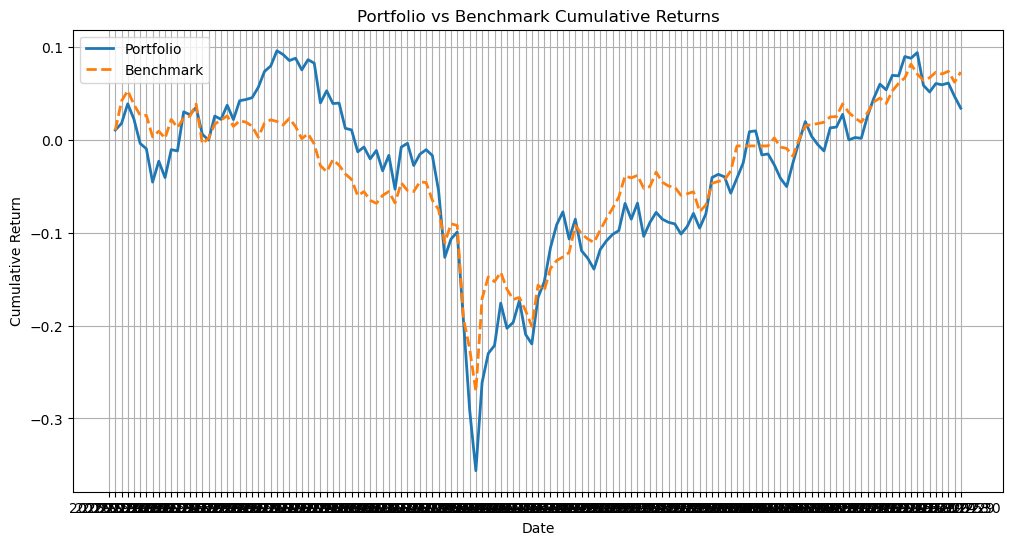

In [58]:
plt.figure(figsize=(12,6))
plt.plot(port_returns, label = 'Portfolio', linewidth=2)
plt.plot(benchmark_returns, label='Benchmark', linewidth=2, linestyle='--')
plt.title("Portfolio vs Benchmark Cumulative Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()
